In [3]:
pip install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 8.8 MB/s eta 0:00:00


In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
# Load the datasets
mutations_df = pd.read_csv('TCGA_GBM_LGG_Mutations_all.csv')
info_with_grade_df = pd.read_csv('TCGA_InfoWithGrade.csv')

# Display the first few rows of each dataframe
mutations_head = mutations_df.head()
info_with_grade_head = info_with_grade_df.head()

# Separate features and target variable
X = info_with_grade_df.drop('Grade', axis=1)
y = info_with_grade_df['Grade']

# Convert categorical variables to numeric if necessary
X = pd.get_dummies(X, drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the shape of the training and testing data
X_train_scaled.shape, X_test_scaled.shape


((671, 23), (168, 23))

In [33]:
joblib.dump(scaler, 'scaler.joblib')


['scaler.joblib']

In [34]:
X_train.columns

Index(['Gender', 'Age_at_diagnosis', 'Race', 'IDH1', 'TP53', 'ATRX', 'PTEN',
       'EGFR', 'CIC', 'MUC16', 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1',
       'NOTCH1', 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4',
       'PDGFRA'],
      dtype='object')

Training Random Forest...
Fitting 3 folds for each of 36 candidates, totalling 108 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


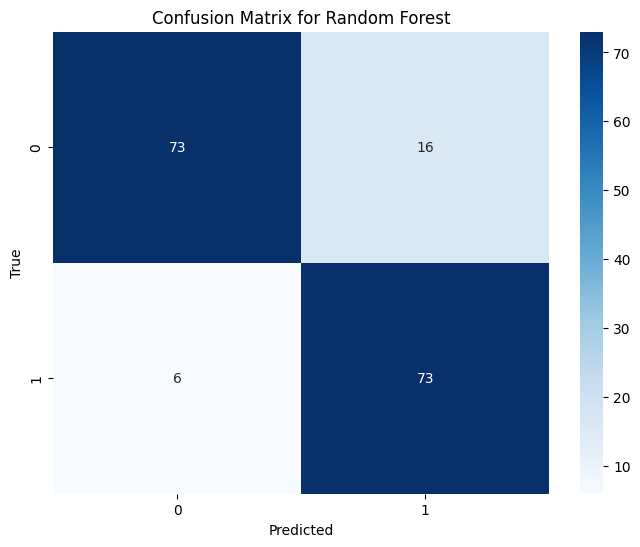

Training Decision Tree...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


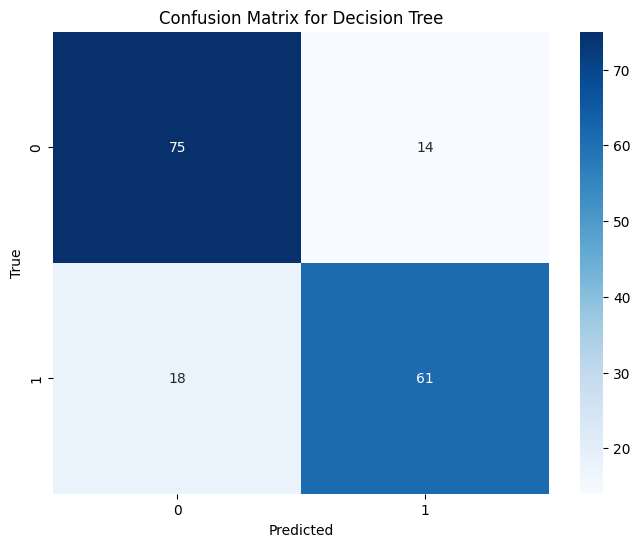

Training Logistic Regression...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


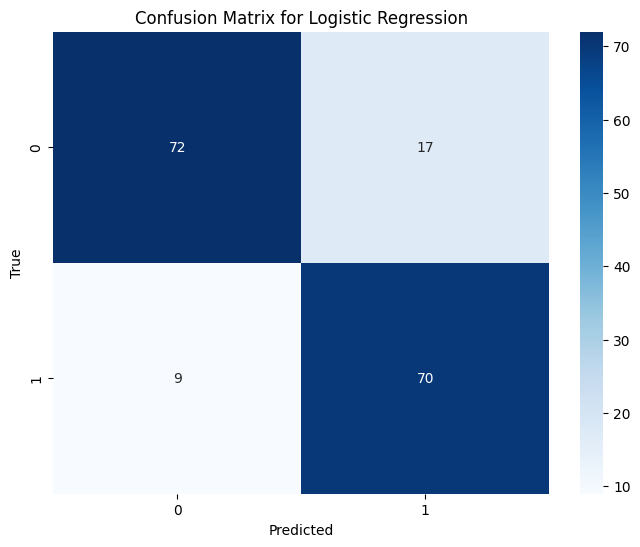

Training KNN...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


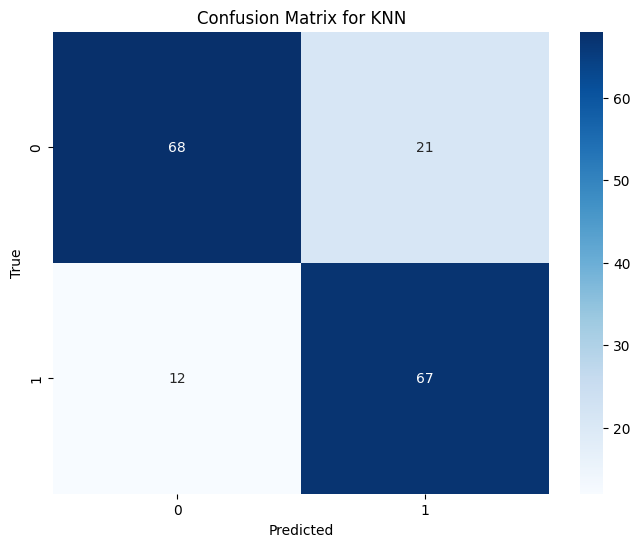

Training Adaboost...
Fitting 3 folds for each of 9 candidates, totalling 27 fits


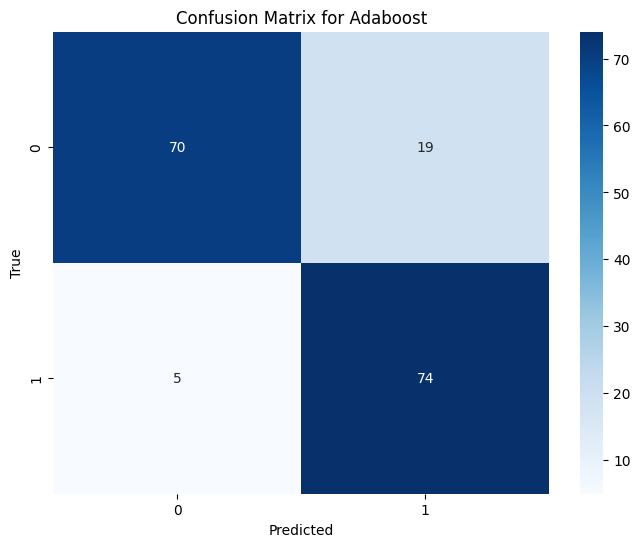

Training SVM...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


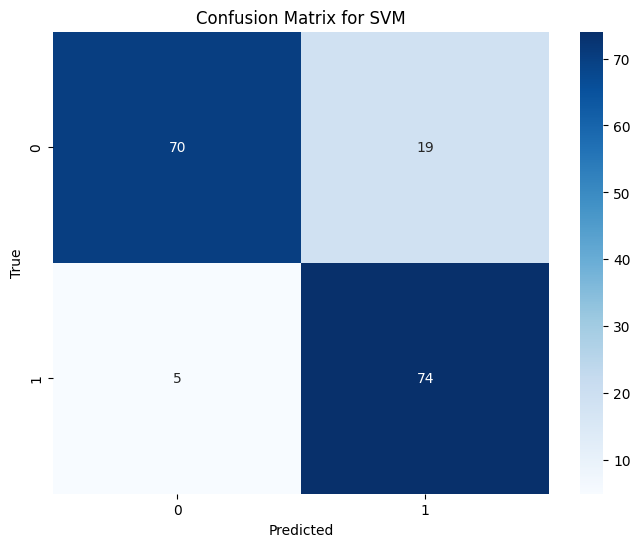

Training LGBM...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 273, number of negative: 398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000278 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 286
[LightGBM] [Info] Number of data points in the train set: 671, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.406855 -> initscore=-0.376980
[LightGBM] [Info] Start training from score -0.376980
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

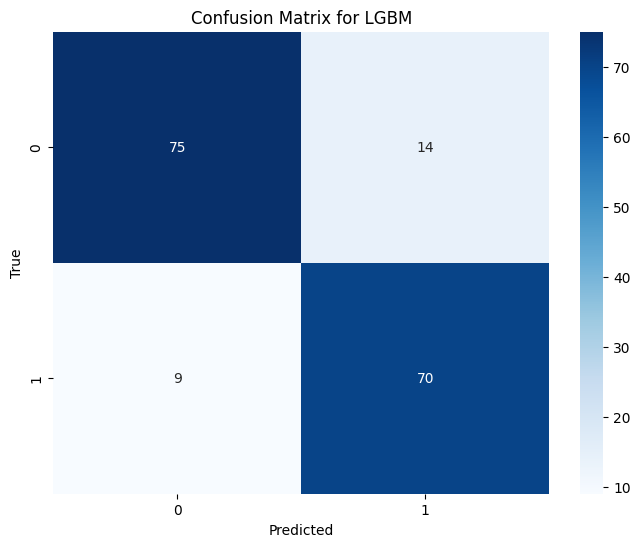

Training XGBoost...
Fitting 3 folds for each of 24 candidates, totalling 72 fits


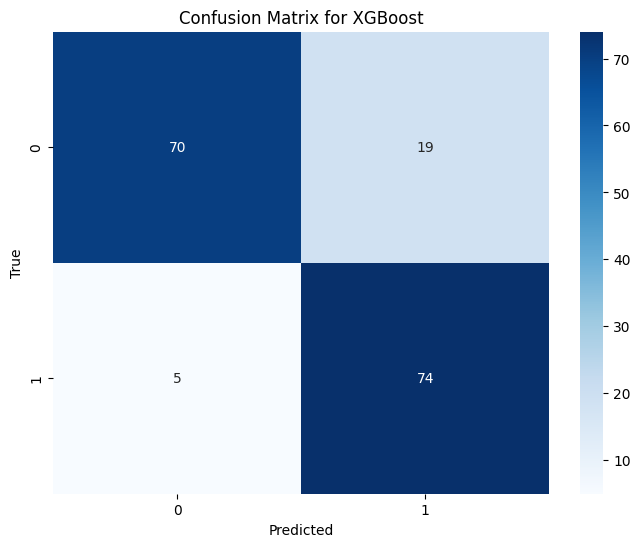

Training CatBoost...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


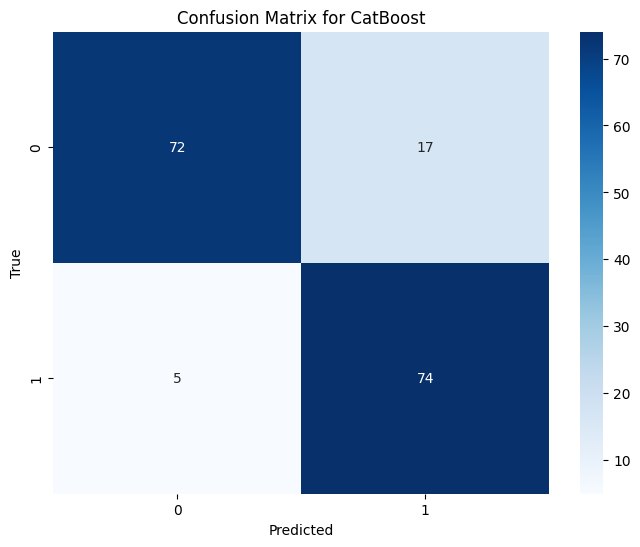

                     Accuracy  \
Random Forest        0.869048   
Decision Tree        0.809524   
Logistic Regression  0.845238   
KNN                  0.803571   
Adaboost             0.857143   
SVM                  0.857143   
LGBM                 0.863095   
XGBoost              0.857143   
CatBoost             0.869048   

                                                           Best Params  
Random Forest        {'max_depth': 10, 'min_samples_leaf': 1, 'min_...  
Decision Tree        {'max_depth': 10, 'min_samples_leaf': 2, 'min_...  
Logistic Regression                       {'C': 10, 'solver': 'lbfgs'}  
KNN                           {'n_neighbors': 7, 'weights': 'uniform'}  
Adaboost                   {'learning_rate': 0.1, 'n_estimators': 100}  
SVM                   {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}  
LGBM                 {'learning_rate': 0.01, 'max_depth': 10, 'n_es...  
XGBoost              {'learning_rate': 0.01, 'max_depth': 3, 'n_est...  
CatBoost    

In [35]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import joblib

# Define parameter grids for various models
param_grids = {
    "Random Forest": {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    "Decision Tree": {
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    "Logistic Regression": {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'saga']
    },
    "KNN": {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance']
    },
    "SVM": {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    },
    "Adaboost": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1]
    },
    "XGBoost": {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1],
        'subsample': [0.8, 1]
    },
    "LGBM": {
        'num_leaves': [31, 50],
        'max_depth': [10, 20],
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 200]
    },
    "CatBoost": {
        'iterations': [100, 200],
        'depth': [4, 6, 10],
        'learning_rate': [0.01, 0.1]
    }
}

# Initialize models
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "KNN": KNeighborsClassifier(),
    "Adaboost": AdaBoostClassifier(),
    "SVM": SVC(),
    "LGBM": lgb.LGBMClassifier(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "CatBoost": cb.CatBoostClassifier(verbose=0)
}

# Train and evaluate models with hyperparameter tuning
results = {}
for model_name, model in models.items():
    print(f"Training {model_name}...")
    grid_search = GridSearchCV(estimator=model, param_grid=param_grids[model_name], cv=3, n_jobs=-1, verbose=1)
    grid_search.fit(X_train_scaled, y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[model_name] = {"best_params": grid_search.best_params_, "accuracy": accuracy, "report": report}

    # Save the best model
    joblib.dump(best_model, f'{model_name}_best_model.pkl')

    # Draw confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Convert results to DataFrame for better visualization
results_df = pd.DataFrame({model_name: {"Accuracy": details["accuracy"], "Best Params": details["best_params"]} for model_name, details in results.items()}).T

print(results_df)


In [25]:

# Optionally, display the classification report for a specific model
print("Classification Report for XGBoost:\n", results['XGBoost']['report'])

Classification Report for XGBoost:
 {'0': {'precision': 0.9333333333333333, 'recall': 0.7865168539325843, 'f1-score': 0.853658536585366, 'support': 89}, '1': {'precision': 0.7956989247311828, 'recall': 0.9367088607594937, 'f1-score': 0.8604651162790697, 'support': 79}, 'accuracy': 0.8571428571428571, 'macro avg': {'precision': 0.864516129032258, 'recall': 0.861612857346039, 'f1-score': 0.8570618264322178, 'support': 168}, 'weighted avg': {'precision': 0.8686123911930365, 'recall': 0.8571428571428571, 'f1-score': 0.8568592496556194, 'support': 168}}


In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Reshape
from tensorflow.keras.layers import Dropout, BatchNormalization
# Define the ANN model
ann_model = Sequential([
    Dense(256, input_shape=(X_train_scaled.shape[1],), activation='relu'),
    Dropout(0.1),
    Dense(128, activation='relu'),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
ann_history = ann_model.fit(X_train_scaled, y_train, epochs=50, validation_split=0.2, verbose=0)

# Evaluate the model
ann_loss, ann_accuracy = ann_model.evaluate(X_test_scaled, y_test, verbose=0)
ann_report = classification_report(y_test, (ann_model.predict(X_test_scaled) > 0.5).astype(int))

results["ANN"] = {"accuracy": ann_accuracy, "report": ann_report}

# Define the CNN model
cnn_model = Sequential([
    Reshape((X_train_scaled.shape[1], 1), input_shape=(X_train_scaled.shape[1],)),
    Conv1D(512, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Conv1D(256, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

# Compile the model
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
cnn_history = cnn_model.fit(X_train_scaled, y_train, epochs=50, validation_split=0.2, verbose=0)

# Evaluate the model
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_scaled, y_test, verbose=0)
cnn_report = classification_report(y_test, (cnn_model.predict(X_test_scaled) > 0.5).astype(int))

results["CNN"] = {"accuracy": cnn_accuracy, "report": cnn_report}

# Display the results
print(f"ANN Accuracy: {ann_accuracy}")
print(f"ANN Classification Report: {ann_report}")
print(f"CNN Accuracy: {cnn_accuracy}")
print(f"CNN Classification Report: {cnn_report}")


6/6 [==============================] - 0s 7ms/step
ANN Accuracy: 0.7916666865348816
ANN Classification Report:               precision    recall  f1-score   support

           0       0.83      0.76      0.80        89
           1       0.76      0.82      0.79        79

    accuracy                           0.79       168
   macro avg       0.79      0.79      0.79       168
weighted avg       0.79      0.79      0.79       168

CNN Accuracy: 0.8214285969734192
CNN Classification Report:               precision    recall  f1-score   support

           0       0.86      0.79      0.82        89
           1       0.78      0.86      0.82        79

    accuracy                           0.82       168
   macro avg       0.82      0.82      0.82       168
weighted avg       0.83      0.82      0.82       168



In [41]:
cnn_model.save("cnn.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [42]:
ann_model.save("Ann.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


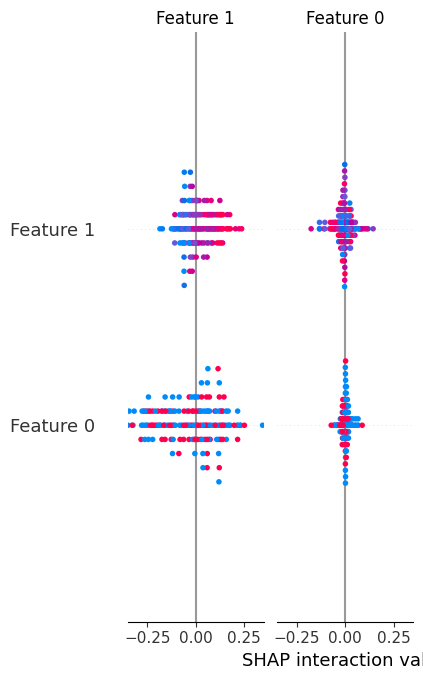

In [13]:
import shap

# Initialize the SHAP explainer for the Random Forest model
explainer = shap.Explainer(models["Random Forest"], X_train_scaled)
shap_values = explainer(X_test_scaled,check_additivity=False)

# Plot the SHAP values
shap.summary_plot(shap_values, X_test_scaled)


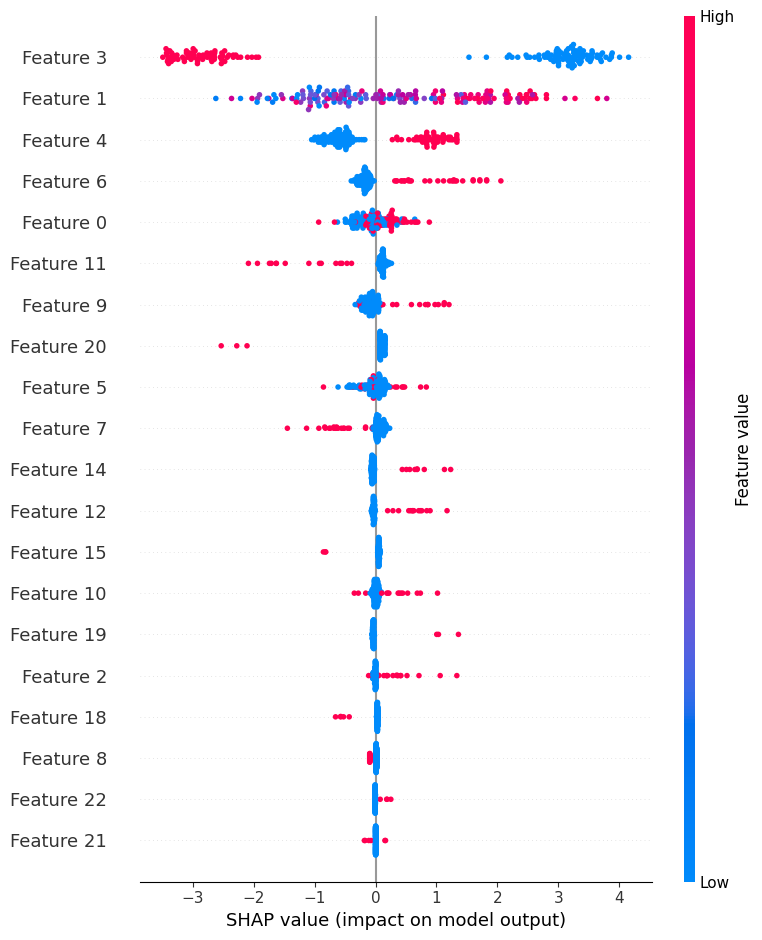

In [14]:
import shap

# Initialize the SHAP explainer for the XGBoost model
explainer = shap.Explainer(models["XGBoost"], X_train_scaled)
shap_values = explainer(X_test_scaled)

# Plot the SHAP values
shap.summary_plot(shap_values, X_test_scaled)


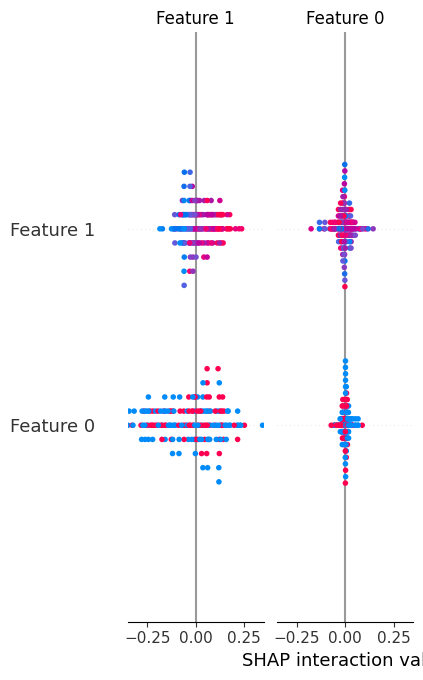

In [18]:
import shap

# Initialize the SHAP explainer for the XGBoost model
explainer = shap.Explainer(models["Random Forest"], X_train_scaled)
shap_values = explainer(X_test_scaled,check_additivity=False)

# Plot the SHAP values
shap.summary_plot(shap_values, X_test_scaled)


In [36]:
# Step 1: Import necessary libraries
import joblib
import pandas as pd
import numpy as np

# Step 2: Load the saved Random Forest model
model = joblib.load('Random Forest_best_model.pkl')

# Step 3: Define a single input value
# Replace these values with your actual input values
single_input = {
    'Gender': 1,
    'Age_at_diagnosis': 45,
    'Race': 2,
    'IDH1': 0,
    'TP53': 1,
    'ATRX': 0,
    'PTEN': 1,
    'EGFR': 0,
    'CIC': 0,
    'MUC16': 1,
    'PIK3CA': 0,
    'NF1': 1,
    'PIK3R1': 0,
    'FUBP1': 0,
    'RB1': 1,
    'NOTCH1': 0,
    'BCOR': 0,
    'CSMD3': 1,
    'SMARCA4': 0,
    'GRIN2A': 0,
    'IDH2': 0,
    'FAT4': 1,
    'PDGFRA': 0
}

# Convert the input to a DataFrame
single_input_df = pd.DataFrame([single_input])

# Step 4: Preprocess the input data
# Load the scaler used during training
scaler = joblib.load('scaler.joblib')
single_input_scaled = scaler.transform(single_input_df)

# Step 5: Make a prediction
prediction = model.predict(single_input_scaled)

# Step 6: Output the prediction
print(f'The prediction for the input is: {prediction[0]}')


The prediction for the input is: 1


In [ ]:
# Step 1: Import necessary libraries
import joblib
import pandas as pd
import numpy as np

# Step 2: Load the saved Random Forest model
model = joblib.load('Random Forest_best_model.pkl')

# Step 3: Define a single input value for class 0
single_input_class_0 = {
    'Gender': 0,
    'Age_at_diagnosis': 60,
    'Race': 1,
    'IDH1': 0,
    'TP53': 0,
    'ATRX': 0,
    'PTEN': 0,
    'EGFR': 0,
    'CIC': 0,
    'MUC16': 0,
    'PIK3CA': 0,
    'NF1': 0,
    'PIK3R1': 0,
    'FUBP1': 0,
    'RB1': 0,
    'NOTCH1': 0,
    'BCOR': 0,
    'CSMD3': 0,
    'SMARCA4': 0,
    'GRIN2A': 0,
    'IDH2': 0,
    'FAT4': 0,
    'PDGFRA': 0
}

# Convert the input to a DataFrame
single_input_df_class_0 = pd.DataFrame([single_input_class_0])

# Step 4: Preprocess the input data
# Load the scaler used during training
scaler = joblib.load('scaler.joblib')
single_input_scaled_class_0 = scaler.transform(single_input_df_class_0)

# Step 5: Make a prediction
prediction_class_0 = model.predict(single_input_scaled_class_0)

# Step 6: Output the prediction
print(f'The prediction for the input is: {prediction_class_0[0]}')


The prediction for the input is: 1


In [39]:
# Step 1: Import necessary libraries
import joblib
import pandas as pd
import numpy as np

# Step 2: Load the saved Random Forest model
model = joblib.load('Random Forest_best_model.pkl')

# Step 3: Define a single input value for class 0
single_input_class_1 = {
    'Gender': 0,
    'Age_at_diagnosis': 60,
    'Race': 1,
    'IDH1': 0,
    'TP53': 0,
    'ATRX': 0,
    'PTEN': 0,
    'EGFR': 0,
    'CIC': 0,
    'MUC16': 0,
    'PIK3CA': 0,
    'NF1': 0,
    'PIK3R1': 0,
    'FUBP1': 0,
    'RB1': 0,
    'NOTCH1': 0,
    'BCOR': 0,
    'CSMD3': 0,
    'SMARCA4': 0,
    'GRIN2A': 0,
    'IDH2': 0,
    'FAT4': 0,
    'PDGFRA': 0
}

# Convert the input to a DataFrame
single_input_df_class_1 = pd.DataFrame([single_input_class_1])

# Step 4: Preprocess the input data
# Load the scaler used during training
scaler = joblib.load('scaler.joblib')
single_input_scaled_class_1 = scaler.transform(single_input_df_class_1)

# Step 5: Make a prediction
prediction_class_1 = model.predict(single_input_scaled_class_1)

# Step 6: Output the prediction for class 1
print(f'The prediction for the input (class 1) is: {prediction_class_1[0]}')

# Step 3: Define a single input value for class 0
single_input_class_0 = {
    'Gender': 1,
    'Age_at_diagnosis': 45,
    'Race': 2,
    'IDH1': 1,
    'TP53': 1,
    'ATRX': 1,
    'PTEN': 1,
    'EGFR': 1,
    'CIC': 1,
    'MUC16': 1,
    'PIK3CA': 1,
    'NF1': 1,
    'PIK3R1': 1,
    'FUBP1': 1,
    'RB1': 1,
    'NOTCH1': 1,
    'BCOR': 1,
    'CSMD3': 1,
    'SMARCA4': 1,
    'GRIN2A': 1,
    'IDH2': 1,
    'FAT4': 1,
    'PDGFRA': 1
}

# Convert the input to a DataFrame
single_input_df_class_0 = pd.DataFrame([single_input_class_0])

# Step 4: Preprocess the input data
single_input_scaled_class_0 = scaler.transform(single_input_df_class_0)

# Step 5: Make a prediction
prediction_class_0 = model.predict(single_input_scaled_class_0)

# Step 6: Output the prediction for class 0
print(f'The prediction for the input (class 0) is: {prediction_class_0[0]}')


The prediction for the input (class 1) is: 1
The prediction for the input (class 0) is: 0


In [40]:
# prompt: download all the saved model files in local system

from google.colab import files

# Get a list of all the saved model files
model_files = !find . -name "*.pkl"

# Download each file
for file in model_files:
  files.download(file)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>